# Oxford-IIIT Pet Results Comparison Notebook

This notebook compares the saved experiment CSV files for:

- Baseline CNN from scratch
- ResNet18 transfer learning
- ConvNeXt Tiny transfer learning
- ViT Base Patch16 transfer learning

## 1. Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path(".")  # change this if the CSVs are in another folder
FIG_DIR = Path("comparison_figures")
FIG_DIR.mkdir(exist_ok=True)

CSV_FILES = {
    "baseline": "experiment_results_with_baseline.csv",
    "resnet18": "resnet18_experiment_results.csv",
    "convnext": "convnext_experiment_results.csv",
    "vit": "vit_experiment_results.csv",
}

## 2. Load and standardize all CSV files

In [2]:
def load_results(data_dir=DATA_DIR):
    frames = []
    for source, filename in CSV_FILES.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path.resolve()}")
        df = pd.read_csv(path)
        df["source_file"] = filename
        df["architecture_group"] = source
        frames.append(df)
    return pd.concat(frames, ignore_index=True, sort=False)

raw = load_results()
raw.head()

,name,lr,batch_size,dropout,batchnorm,augmentation,optimizer,epochs,best_epoch,best_val_acc,final_val_acc,test_acc,model,pretrained,strategy,image_size,weight_decay,label_smoothing,scheduler,test_loss,macro_precision,macro_recall,source_file,architecture_group
0,BASELINE_100_epochs,0.0010,32,0.4,True,baseline,adamw,100,100.0,0.7174,0.7174,0.6225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,experiment_results_with_baseline.csv,baseline
1,EXP1_baseline_ref,0.0010,32,0.4,True,baseline,adamw,30,30.0,0.4158,0.4158,0.3674,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.3244,0.3612,0.3684,experiment_results_with_baseline.csv,baseline
2,EXP4_no_dropout,0.0010,32,0.0,True,baseline,adamw,30,28.0,0.3967,0.3954,0.3472,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.4117,0.3506,0.3480,experiment_results_with_baseline.csv,baseline
3,EXP3_batch64,0.0010,64,0.4,True,baseline,adamw,30,26.0,0.3832,0.3832,0.3197,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.4957,0.3117,0.3205,experiment_results_with_baseline.csv,baseline
4,EXP2_lr_0001,0.0001,32,0.4,True,baseline,adamw,30,23.0,0.3152,0.2908,0.2415,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.8319,0.2342,0.2428,experiment_results_with_baseline.csv,baseline


In [3]:
def standardize_results(df):
    df = df.copy()

    # Fill missing model labels from the file/source context.
    df["model"] = df["model"].fillna("Baseline CNN")
    df.loc[df["architecture_group"].eq("baseline"), "model"] = df.loc[df["architecture_group"].eq("baseline"), "model"].fillna("Baseline CNN")
    df["strategy"] = df["strategy"].fillna("from_scratch")
    df["pretrained"] = df["pretrained"].fillna(False)

    # Make boolean-like columns consistent.
    for col in ["pretrained", "batchnorm"]:
        if col in df.columns:
            df[col] = df[col].map(lambda x: x if isinstance(x, bool) else str(x).lower() == "true" if pd.notna(x) else np.nan)

    # Add useful derived metrics.
    df["val_test_gap"] = df["best_val_acc"] - df["test_acc"]
    df["f1_macro_est"] = 2 * (df["macro_precision"] * df["macro_recall"]) / (df["macro_precision"] + df["macro_recall"])
    df["f1_macro_est"] = df["f1_macro_est"].replace([np.inf, -np.inf], np.nan)
    df["error_rate"] = 1 - df["test_acc"]
    df["experiment_label"] = df["model"].astype(str) + " | " + df["name"].astype(str)

    # A simple cost proxy: epochs only. Replace/add wall-clock time or parameter count if you have it.
    df["training_cost_proxy_epochs"] = df["epochs"]

    return df

results = standardize_results(raw)
print(results.shape)
results.sort_values("test_acc", ascending=False).head(10)

(23, 29)


,name,lr,batch_size,dropout,batchnorm,augmentation,optimizer,epochs,best_epoch,best_val_acc,final_val_acc,test_acc,model,pretrained,strategy,image_size,weight_decay,label_smoothing,scheduler,test_loss,macro_precision,macro_recall,source_file,architecture_group,val_test_gap,f1_macro_est,error_rate,experiment_label,training_cost_proxy_epochs
13,exp2_convnext_img256,0.00050,24,0.1,NaN,baseline,adamw,20,NaN,0.9688,NaN,0.9406,ConvNeXt Tiny,True,last_block,256.0,0.0001,0.05,cosine,NaN,0.9418,0.9400,convnext_experiment_results.csv,convnext,0.0282,0.940899,0.0594,ConvNeXt Tiny | exp2_convnext_img256,20
14,exp4_convnext_last_two_blocks,0.00005,16,0.2,NaN,baseline,adamw,30,NaN,0.9660,NaN,0.9387,ConvNeXt Tiny,True,last_two_blocks,224.0,0.0010,0.05,cosine,NaN,0.9392,0.9383,convnext_experiment_results.csv,convnext,0.0273,0.938750,0.0613,ConvNeXt Tiny | exp4_convnext_last_two_blocks,30
15,exp1_convnext_lr_5e4,0.00050,32,0.1,NaN,baseline,adamw,20,NaN,0.9633,NaN,0.9330,ConvNeXt Tiny,True,last_block,224.0,0.0001,0.05,cosine,NaN,0.9345,0.9325,convnext_experiment_results.csv,convnext,0.0303,0.933499,0.0670,ConvNeXt Tiny | exp1_convnext_lr_5e4,20
18,exp3_vit_last_block,0.00010,16,0.1,NaN,baseline,adamw,25,NaN,0.9552,NaN,0.9316,ViT Base Patch16 224,True,last_block,224.0,0.0005,0.05,plateau,NaN,0.9330,0.9309,vit_experiment_results.csv,vit,0.0236,0.931949,0.0684,ViT Base Patch16 224 | exp3_vit_last_block,25
19,exp4_vit_last_two_blocks,0.00005,8,0.2,NaN,baseline,adamw,30,NaN,0.9524,NaN,0.9289,ViT Base Patch16 224,True,last_two_blocks,224.0,0.0010,0.05,plateau,NaN,0.9307,0.9286,vit_experiment_results.csv,vit,0.0235,0.929649,0.0711,ViT Base Patch16 224 | exp4_vit_last_two_blocks,30
20,exp5_vit_full_finetune,0.00001,8,0.2,NaN,strong,adamw,30,NaN,0.9552,NaN,0.9283,ViT Base Patch16 224,True,full_finetune,224.0,0.0010,0.05,plateau,NaN,0.9295,0.9280,vit_experiment_results.csv,vit,0.0269,0.928749,0.0717,ViT Base Patch16 224 | exp5_vit_full_finetune,30
16,exp3_convnext_classifier_only,0.00100,32,0.2,NaN,strong,adamw,20,NaN,0.9552,NaN,0.9248,ConvNeXt Tiny,True,classifier_only,224.0,0.0001,0.05,cosine,NaN,0.9283,0.9245,convnext_experiment_results.csv,convnext,0.0304,0.926396,0.0752,ConvNeXt Tiny | exp3_convnext_classifier_only,20
17,exp5_convnext_full_finetune,0.00001,16,0.2,NaN,strong,adamw,30,NaN,0.9538,NaN,0.9237,ConvNeXt Tiny,True,full_finetune,224.0,0.0010,0.05,cosine,NaN,0.9271,0.9236,convnext_experiment_results.csv,convnext,0.0301,0.925347,0.0763,ConvNeXt Tiny | exp5_convnext_full_finetune,30
21,exp1_vit_classifier_lr1e3,0.00100,16,0.1,NaN,baseline,adamw,20,NaN,0.9457,NaN,0.9229,ViT Base Patch16 224,True,classifier_only,224.0,0.0001,0.05,plateau,NaN,0.9248,0.9227,vit_experiment_results.csv,vit,0.0228,0.923749,0.0771,ViT Base Patch16 224 | exp1_vit_classifier_lr1e3,20
22,exp2_vit_classifier_strong_aug,0.00050,16,0.2,NaN,strong,adamw,20,NaN,0.9402,NaN,0.9191,ViT Base Patch16 224,True,classifier_only,224.0,0.0005,0.05,plateau,NaN,0.9203,0.9186,vit_experiment_results.csv,vit,0.0211,0.919449,0.0809,ViT Base Patch16 224 | exp2_vit_classifier_str...,20


## 3. Quick overview tables

In [4]:
metric_cols = ["best_val_acc", "test_acc", "macro_precision", "macro_recall", "f1_macro_est", "val_test_gap"]

all_experiments = (
    results[["name", "model", "pretrained", "strategy", "lr", "batch_size", "dropout", "batchnorm", "augmentation", "optimizer", "epochs"] + metric_cols]
    .sort_values("test_acc", ascending=False)
    .reset_index(drop=True)
)

all_experiments

,name,model,pretrained,strategy,lr,batch_size,dropout,batchnorm,augmentation,optimizer,epochs,best_val_acc,test_acc,macro_precision,macro_recall,f1_macro_est,val_test_gap
0,exp2_convnext_img256,ConvNeXt Tiny,True,last_block,0.00050,24,0.1,NaN,baseline,adamw,20,0.9688,0.9406,0.9418,0.9400,0.940899,0.0282
1,exp4_convnext_last_two_blocks,ConvNeXt Tiny,True,last_two_blocks,0.00005,16,0.2,NaN,baseline,adamw,30,0.9660,0.9387,0.9392,0.9383,0.938750,0.0273
2,exp1_convnext_lr_5e4,ConvNeXt Tiny,True,last_block,0.00050,32,0.1,NaN,baseline,adamw,20,0.9633,0.9330,0.9345,0.9325,0.933499,0.0303
3,exp3_vit_last_block,ViT Base Patch16 224,True,last_block,0.00010,16,0.1,NaN,baseline,adamw,25,0.9552,0.9316,0.9330,0.9309,0.931949,0.0236
4,exp4_vit_last_two_blocks,ViT Base Patch16 224,True,last_two_blocks,0.00005,8,0.2,NaN,baseline,adamw,30,0.9524,0.9289,0.9307,0.9286,0.929649,0.0235
5,exp5_vit_full_finetune,ViT Base Patch16 224,True,full_finetune,0.00001,8,0.2,NaN,strong,adamw,30,0.9552,0.9283,0.9295,0.9280,0.928749,0.0269
6,exp3_convnext_classifier_only,ConvNeXt Tiny,True,classifier_only,0.00100,32,0.2,NaN,strong,adamw,20,0.9552,0.9248,0.9283,0.9245,0.926396,0.0304
7,exp5_convnext_full_finetune,ConvNeXt Tiny,True,full_finetune,0.00001,16,0.2,NaN,strong,adamw,30,0.9538,0.9237,0.9271,0.9236,0.925347,0.0301
8,exp1_vit_classifier_lr1e3,ViT Base Patch16 224,True,classifier_only,0.00100,16,0.1,NaN,baseline,adamw,20,0.9457,0.9229,0.9248,0.9227,0.923749,0.0228
9,exp2_vit_classifier_strong_aug,ViT Base Patch16 224,True,classifier_only,0.00050,16,0.2,NaN,strong,adamw,20,0.9402,0.9191,0.9203,0.9186,0.919449,0.0211


In [5]:
summary_by_model = (
    results.groupby("model", dropna=False)
    .agg(
        experiments=("name", "count"),
        best_test_acc=("test_acc", "max"),
        mean_test_acc=("test_acc", "mean"),
        best_val_acc=("best_val_acc", "max"),
        mean_precision=("macro_precision", "mean"),
        mean_recall=("macro_recall", "mean"),
        mean_epochs=("epochs", "mean"),
    )
    .sort_values("best_test_acc", ascending=False)
)

summary_by_model

,experiments,best_test_acc,mean_test_acc,best_val_acc,mean_precision,mean_recall,mean_epochs
model,,,,,,,
ConvNeXt Tiny,5,0.9406,0.932160,0.9688,0.934180,0.931780,24.0
ViT Base Patch16 224,5,0.9316,0.926160,0.9552,0.927660,0.925760,25.0
ResNet18,6,0.8591,0.838467,0.9022,0.843767,0.837933,20.0
Baseline CNN,7,0.6225,0.306571,0.7174,0.246150,0.254917,40.0


In [6]:
best_per_model = (
    results.sort_values("test_acc", ascending=False)
    .groupby("model", as_index=False)
    .first()[["model", "name", "strategy", "lr", "batch_size", "dropout", "augmentation", "epochs", "best_val_acc", "test_acc", "macro_precision", "macro_recall", "f1_macro_est"]]
    .sort_values("test_acc", ascending=False)
    .reset_index(drop=True)
)

best_per_model

,model,name,strategy,lr,batch_size,dropout,augmentation,epochs,best_val_acc,test_acc,macro_precision,macro_recall,f1_macro_est
0,ConvNeXt Tiny,exp2_convnext_img256,last_block,0.0005,24,0.1,baseline,20,0.9688,0.9406,0.9418,0.9400,0.940899
1,ViT Base Patch16 224,exp3_vit_last_block,last_block,0.0001,16,0.1,baseline,25,0.9552,0.9316,0.9330,0.9309,0.931949
2,ResNet18,ResNet18_03_lr1e4_bs16_layer4_fc,layer4,0.0001,16,0.0,baseline,20,0.9022,0.8591,0.8611,0.8585,0.859798
3,Baseline CNN,BASELINE_100_epochs,from_scratch,0.0010,32,0.4,baseline,100,0.7174,0.6225,0.3612,0.3684,0.364764


## 4. Main comparison plots

Saved: comparison_figures/all_experiments_test_accuracy.png


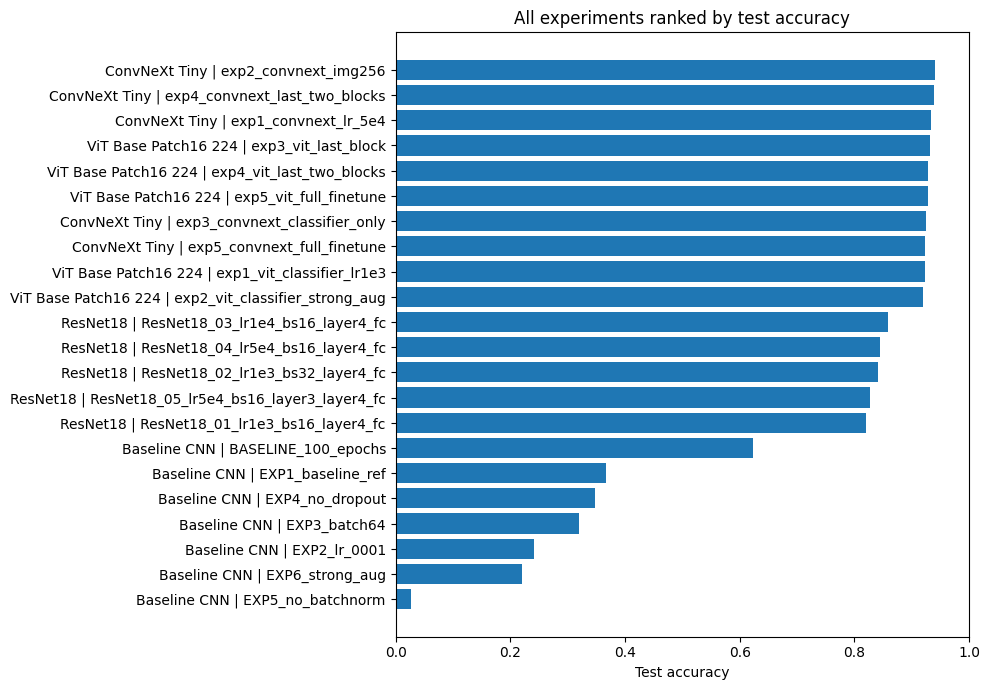

In [7]:
def save_current_fig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")

plot_df = results.sort_values("test_acc", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["experiment_label"], plot_df["test_acc"])
plt.xlabel("Test accuracy")
plt.title("All experiments ranked by test accuracy")
plt.xlim(0, 1.0)
save_current_fig("all_experiments_test_accuracy.png")
plt.show()

Saved: comparison_figures/best_test_accuracy_per_architecture.png


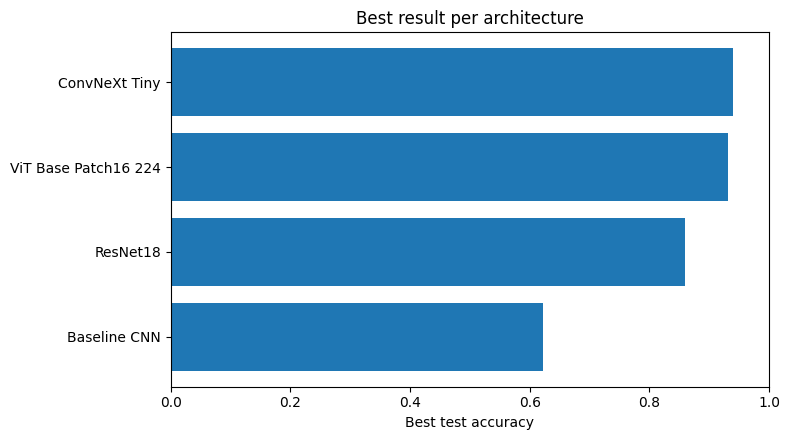

In [8]:
plot_df = best_per_model.sort_values("test_acc", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["model"], plot_df["test_acc"])
plt.xlabel("Best test accuracy")
plt.title("Best result per architecture")
plt.xlim(0, 1.0)
save_current_fig("best_test_accuracy_per_architecture.png")
plt.show()

Saved: comparison_figures/precision_vs_recall.png


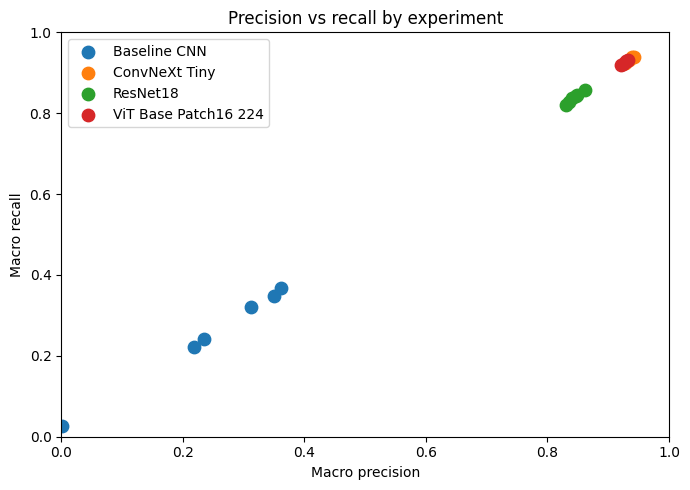

In [9]:
plt.figure(figsize=(7, 5))
for model_name, group in results.groupby("model"):
    plt.scatter(group["macro_precision"], group["macro_recall"], s=80, label=model_name)

plt.xlabel("Macro precision")
plt.ylabel("Macro recall")
plt.title("Precision vs recall by experiment")
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.legend()
save_current_fig("precision_vs_recall.png")
plt.show()

Saved: comparison_figures/validation_vs_test_accuracy.png


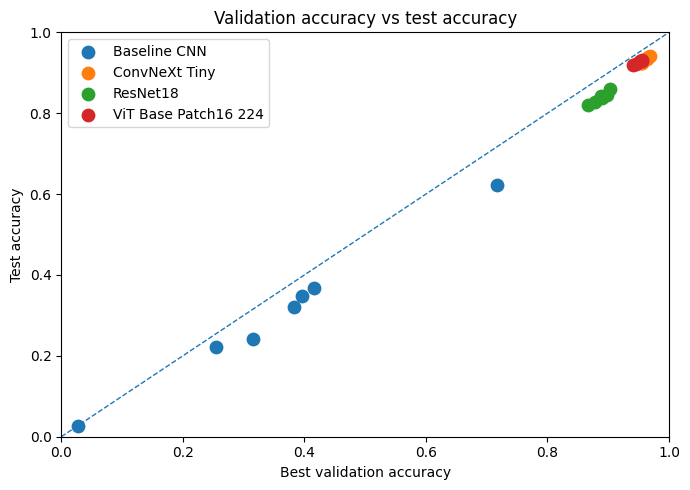

In [10]:
plt.figure(figsize=(7, 5))
for model_name, group in results.groupby("model"):
    plt.scatter(group["best_val_acc"], group["test_acc"], s=80, label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Best validation accuracy")
plt.ylabel("Test accuracy")
plt.title("Validation accuracy vs test accuracy")
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.legend()
save_current_fig("validation_vs_test_accuracy.png")
plt.show()

Saved: comparison_figures/validation_test_gap.png


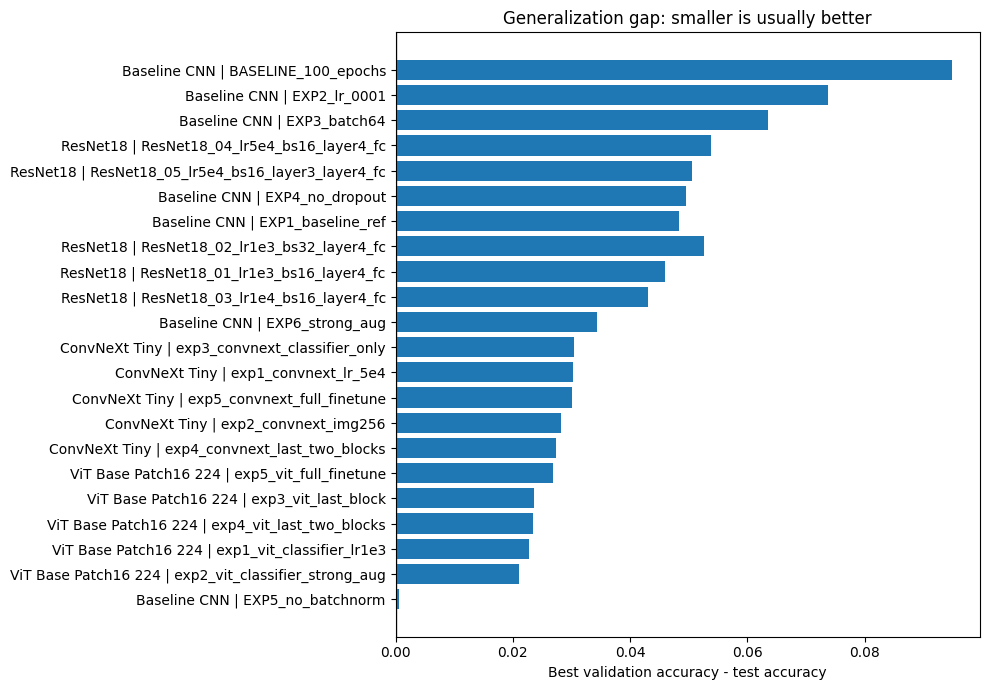

In [11]:
gap_df = results.sort_values("val_test_gap", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(gap_df["experiment_label"], gap_df["val_test_gap"])
plt.axvline(0, linewidth=1)
plt.xlabel("Best validation accuracy - test accuracy")
plt.title("Generalization gap: smaller is usually better")
save_current_fig("validation_test_gap.png")
plt.show()

## 5. Hyperparameter analysis

Saved: comparison_figures/test_acc_vs_lr.png


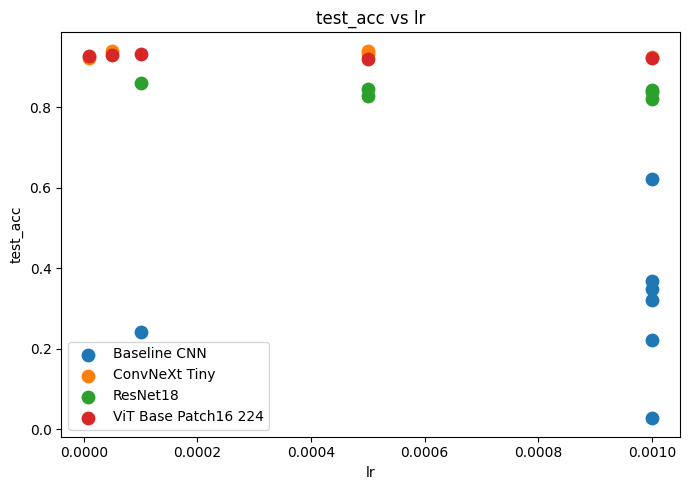

Saved: comparison_figures/test_acc_vs_batch_size.png


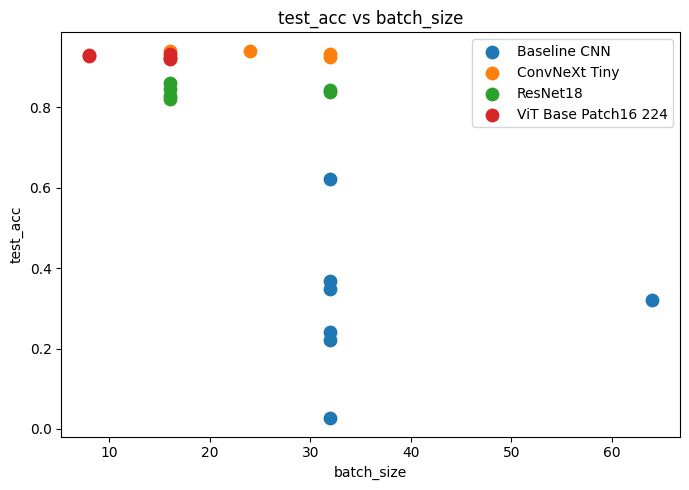

Saved: comparison_figures/test_acc_vs_dropout.png


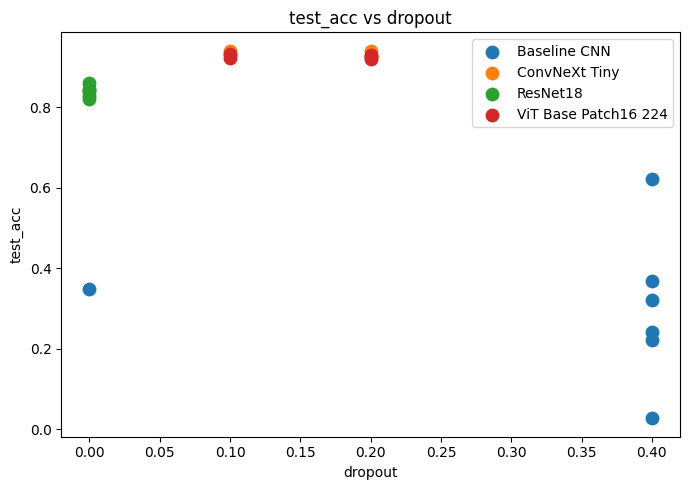

Saved: comparison_figures/test_acc_vs_epochs.png


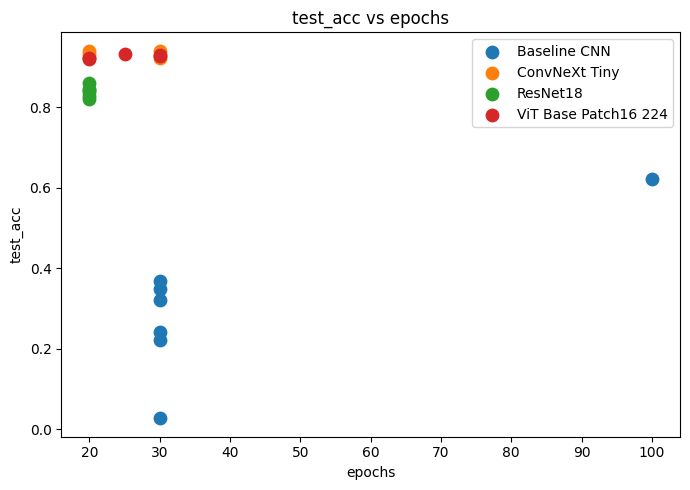

Saved: comparison_figures/test_acc_vs_weight_decay.png


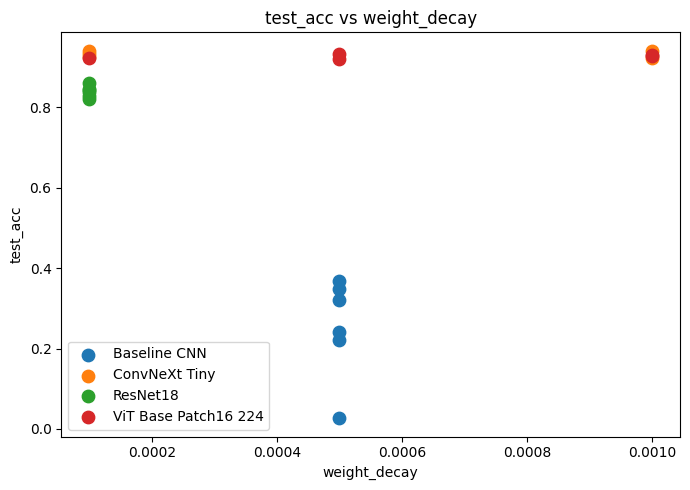

Saved: comparison_figures/test_acc_vs_image_size.png


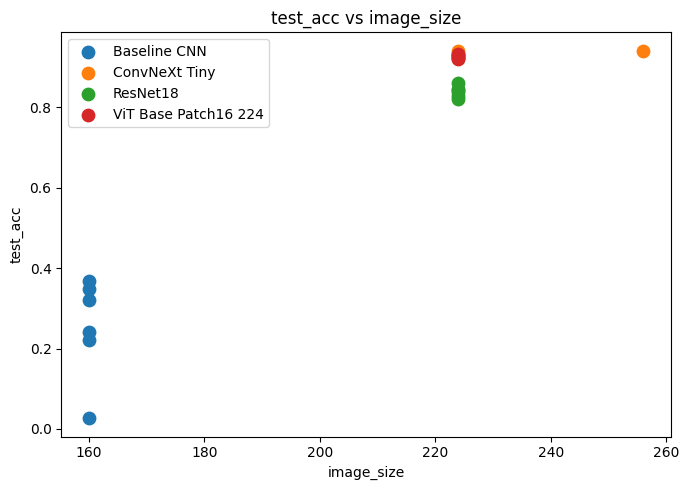

In [12]:
def scatter_metric(x, y="test_acc", label_col="name", data=results):
    plt.figure(figsize=(7, 5))
    for model_name, group in data.groupby("model"):
        plt.scatter(group[x], group[y], s=80, label=model_name)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.legend()
    save_current_fig(f"{y}_vs_{x}.png")
    plt.show()

for col in ["lr", "batch_size", "dropout", "epochs", "weight_decay", "image_size"]:
    if col in results.columns and results[col].notna().sum() > 1:
        scatter_metric(col)

Saved: comparison_figures/test_accuracy_vs_parameter_count.png


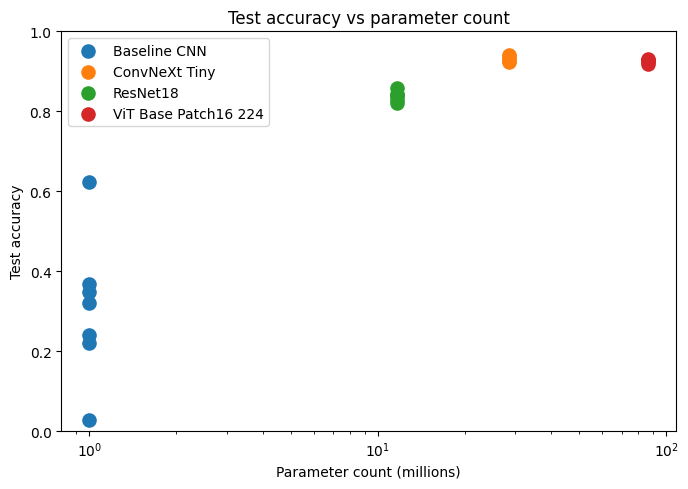

In [23]:
# Parameter count vs test accuracy

PARAM_COUNTS = {
    "Baseline CNN": 1.0,              # replace with your actual count if known
    "ResNet18": 11.7,
    "ConvNeXt Tiny": 28.6,
    "ViT Base Patch16 224": 86.6,
}

# values are in millions of parameters
param_df = results.copy()
param_df["params_millions"] = param_df["model"].map(PARAM_COUNTS)

plt.figure(figsize=(7, 5))

for model_name, group in param_df.groupby("model"):
    plt.scatter(
        group["params_millions"],
        group["test_acc"],
        s=90,
        label=model_name
    )

plt.xlabel("Parameter count (millions)")
plt.ylabel("Test accuracy")
plt.title("Test accuracy vs parameter count")
plt.xscale("log")
plt.ylim(0, 1.0)
plt.legend()
save_current_fig("test_accuracy_vs_parameter_count.png")
plt.show()

Saved: comparison_figures/best_test_accuracy_by_scheduler.png


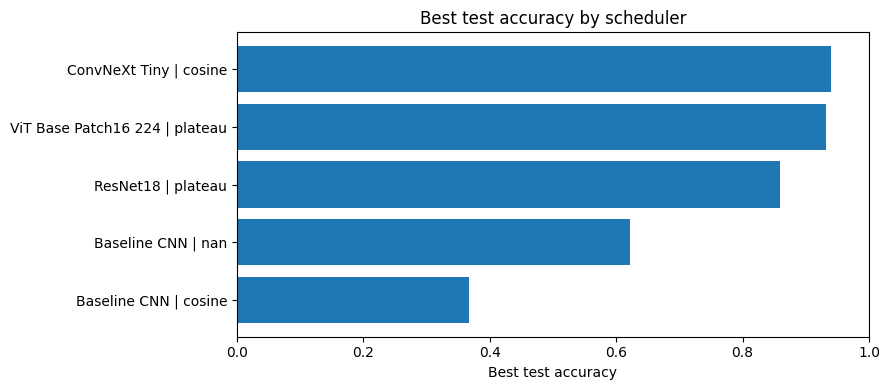

Saved: comparison_figures/best_test_accuracy_by_batchnorm.png


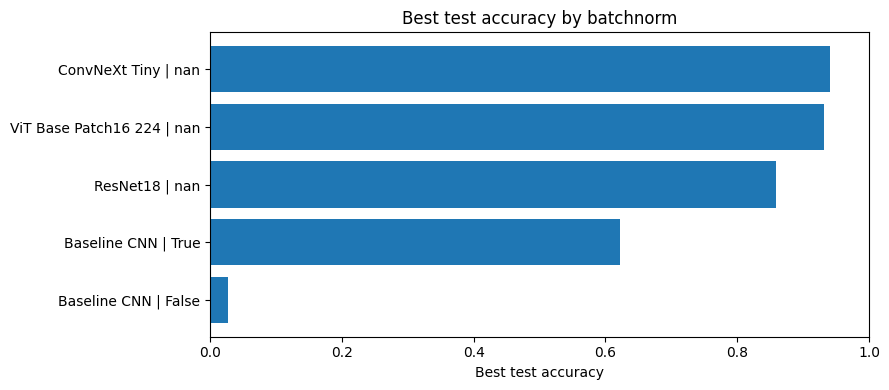

In [13]:
for cat_col in ["strategy", "augmentation", "optimizer", "scheduler", "batchnorm"]:
    if cat_col in results.columns and results[cat_col].notna().nunique() > 1:
        grouped = results.groupby(["model", cat_col], dropna=False)["test_acc"].max().reset_index()
        grouped["label"] = grouped["model"].astype(str) + " | " + grouped[cat_col].astype(str)
        grouped = grouped.sort_values("test_acc", ascending=True)

        plt.figure(figsize=(9, max(4, 0.45 * len(grouped))))
        plt.barh(grouped["label"], grouped["test_acc"])
        plt.xlabel("Best test accuracy")
        plt.title(f"Best test accuracy by {cat_col}")
        plt.xlim(0, 1.0)
        save_current_fig(f"best_test_accuracy_by_{cat_col}.png")
        plt.show()

## 6. Baseline CNN ablation analysis

This section isolates the from-scratch CNN experiments to show the effect of learning rate, batch size, dropout, batch normalization, and augmentation.

In [14]:
baseline = results[results["model"].eq("Baseline CNN")].copy()
baseline.sort_values("test_acc", ascending=False)

,name,lr,batch_size,dropout,batchnorm,augmentation,optimizer,epochs,best_epoch,best_val_acc,final_val_acc,test_acc,model,pretrained,strategy,image_size,weight_decay,label_smoothing,scheduler,test_loss,macro_precision,macro_recall,source_file,architecture_group,val_test_gap,f1_macro_est,error_rate,experiment_label,training_cost_proxy_epochs
0,BASELINE_100_epochs,0.0010,32,0.4,True,baseline,adamw,100,100.0,0.7174,0.7174,0.6225,Baseline CNN,False,from_scratch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,experiment_results_with_baseline.csv,baseline,0.0949,NaN,0.3775,Baseline CNN | BASELINE_100_epochs,100
1,EXP1_baseline_ref,0.0010,32,0.4,True,baseline,adamw,30,30.0,0.4158,0.4158,0.3674,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.3244,0.3612,0.3684,experiment_results_with_baseline.csv,baseline,0.0484,0.364764,0.6326,Baseline CNN | EXP1_baseline_ref,30
2,EXP4_no_dropout,0.0010,32,0.0,True,baseline,adamw,30,28.0,0.3967,0.3954,0.3472,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.4117,0.3506,0.3480,experiment_results_with_baseline.csv,baseline,0.0495,0.349295,0.6528,Baseline CNN | EXP4_no_dropout,30
3,EXP3_batch64,0.0010,64,0.4,True,baseline,adamw,30,26.0,0.3832,0.3832,0.3197,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.4957,0.3117,0.3205,experiment_results_with_baseline.csv,baseline,0.0635,0.316039,0.6803,Baseline CNN | EXP3_batch64,30
4,EXP2_lr_0001,0.0001,32,0.4,True,baseline,adamw,30,23.0,0.3152,0.2908,0.2415,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.8319,0.2342,0.2428,experiment_results_with_baseline.csv,baseline,0.0737,0.238422,0.7585,Baseline CNN | EXP2_lr_0001,30
5,EXP6_strong_aug,0.0010,32,0.4,True,strong,adamw,30,28.0,0.2554,0.2541,0.2210,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,2.7957,0.2185,0.2228,experiment_results_with_baseline.csv,baseline,0.0344,0.220629,0.7790,Baseline CNN | EXP6_strong_aug,30
6,EXP5_no_batchnorm,0.0010,32,0.4,False,baseline,adamw,30,1.0,0.0272,0.0272,0.0267,Baseline CNN,False,from_scratch,160.0,0.0005,0.05,cosine,3.6113,0.0007,0.0270,experiment_results_with_baseline.csv,baseline,0.0005,0.001365,0.9733,Baseline CNN | EXP5_no_batchnorm,30


Saved: comparison_figures/baseline_cnn_ablations.png


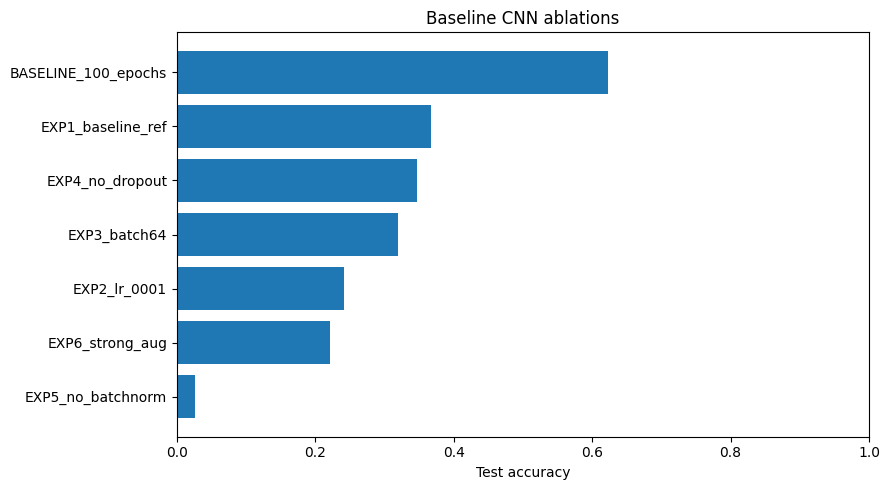

In [15]:
if len(baseline) > 0:
    plot_df = baseline.sort_values("test_acc", ascending=True)
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["name"], plot_df["test_acc"])
    plt.xlabel("Test accuracy")
    plt.title("Baseline CNN ablations")
    plt.xlim(0, 1.0)
    save_current_fig("baseline_cnn_ablations.png")
    plt.show()

## 7. Transfer-learning strategy comparison

This section compares classifier-only, last-block, last-two-blocks, and full-finetuning strategies for ConvNeXt and ViT.

In [16]:
transfer = results[results["pretrained"].eq(True)].copy()
transfer.sort_values("test_acc", ascending=False)

,name,lr,batch_size,dropout,batchnorm,augmentation,optimizer,epochs,best_epoch,best_val_acc,final_val_acc,test_acc,model,pretrained,strategy,image_size,weight_decay,label_smoothing,scheduler,test_loss,macro_precision,macro_recall,source_file,architecture_group,val_test_gap,f1_macro_est,error_rate,experiment_label,training_cost_proxy_epochs
13,exp2_convnext_img256,0.00050,24,0.1,NaN,baseline,adamw,20,NaN,0.9688,NaN,0.9406,ConvNeXt Tiny,True,last_block,256.0,0.0001,0.05,cosine,NaN,0.9418,0.9400,convnext_experiment_results.csv,convnext,0.0282,0.940899,0.0594,ConvNeXt Tiny | exp2_convnext_img256,20
14,exp4_convnext_last_two_blocks,0.00005,16,0.2,NaN,baseline,adamw,30,NaN,0.9660,NaN,0.9387,ConvNeXt Tiny,True,last_two_blocks,224.0,0.0010,0.05,cosine,NaN,0.9392,0.9383,convnext_experiment_results.csv,convnext,0.0273,0.938750,0.0613,ConvNeXt Tiny | exp4_convnext_last_two_blocks,30
15,exp1_convnext_lr_5e4,0.00050,32,0.1,NaN,baseline,adamw,20,NaN,0.9633,NaN,0.9330,ConvNeXt Tiny,True,last_block,224.0,0.0001,0.05,cosine,NaN,0.9345,0.9325,convnext_experiment_results.csv,convnext,0.0303,0.933499,0.0670,ConvNeXt Tiny | exp1_convnext_lr_5e4,20
18,exp3_vit_last_block,0.00010,16,0.1,NaN,baseline,adamw,25,NaN,0.9552,NaN,0.9316,ViT Base Patch16 224,True,last_block,224.0,0.0005,0.05,plateau,NaN,0.9330,0.9309,vit_experiment_results.csv,vit,0.0236,0.931949,0.0684,ViT Base Patch16 224 | exp3_vit_last_block,25
19,exp4_vit_last_two_blocks,0.00005,8,0.2,NaN,baseline,adamw,30,NaN,0.9524,NaN,0.9289,ViT Base Patch16 224,True,last_two_blocks,224.0,0.0010,0.05,plateau,NaN,0.9307,0.9286,vit_experiment_results.csv,vit,0.0235,0.929649,0.0711,ViT Base Patch16 224 | exp4_vit_last_two_blocks,30
20,exp5_vit_full_finetune,0.00001,8,0.2,NaN,strong,adamw,30,NaN,0.9552,NaN,0.9283,ViT Base Patch16 224,True,full_finetune,224.0,0.0010,0.05,plateau,NaN,0.9295,0.9280,vit_experiment_results.csv,vit,0.0269,0.928749,0.0717,ViT Base Patch16 224 | exp5_vit_full_finetune,30
16,exp3_convnext_classifier_only,0.00100,32,0.2,NaN,strong,adamw,20,NaN,0.9552,NaN,0.9248,ConvNeXt Tiny,True,classifier_only,224.0,0.0001,0.05,cosine,NaN,0.9283,0.9245,convnext_experiment_results.csv,convnext,0.0304,0.926396,0.0752,ConvNeXt Tiny | exp3_convnext_classifier_only,20
17,exp5_convnext_full_finetune,0.00001,16,0.2,NaN,strong,adamw,30,NaN,0.9538,NaN,0.9237,ConvNeXt Tiny,True,full_finetune,224.0,0.0010,0.05,cosine,NaN,0.9271,0.9236,convnext_experiment_results.csv,convnext,0.0301,0.925347,0.0763,ConvNeXt Tiny | exp5_convnext_full_finetune,30
21,exp1_vit_classifier_lr1e3,0.00100,16,0.1,NaN,baseline,adamw,20,NaN,0.9457,NaN,0.9229,ViT Base Patch16 224,True,classifier_only,224.0,0.0001,0.05,plateau,NaN,0.9248,0.9227,vit_experiment_results.csv,vit,0.0228,0.923749,0.0771,ViT Base Patch16 224 | exp1_vit_classifier_lr1e3,20
22,exp2_vit_classifier_strong_aug,0.00050,16,0.2,NaN,strong,adamw,20,NaN,0.9402,NaN,0.9191,ViT Base Patch16 224,True,classifier_only,224.0,0.0005,0.05,plateau,NaN,0.9203,0.9186,vit_experiment_results.csv,vit,0.0211,0.919449,0.0809,ViT Base Patch16 224 | exp2_vit_classifier_str...,20


Saved: comparison_figures/transfer_strategy_comparison.png


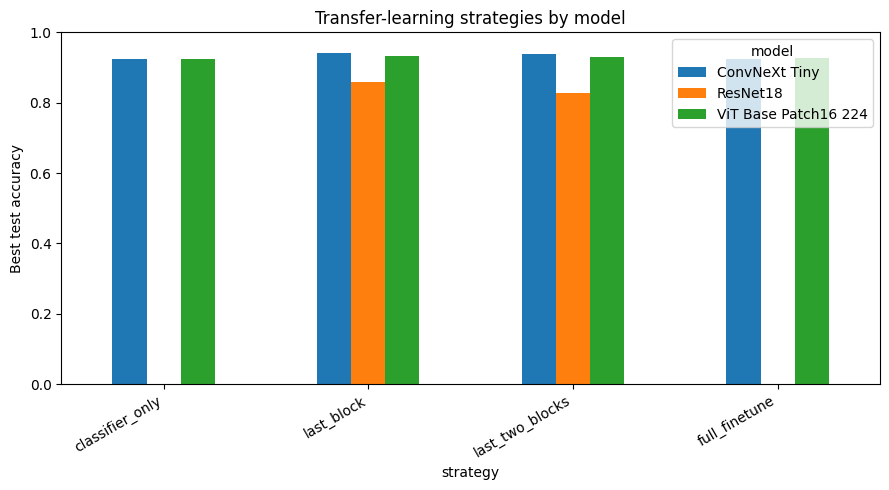

model,ConvNeXt Tiny,ResNet18,ViT Base Patch16 224
strategy,,,
classifier_only,0.9248,NaN,0.9229
last_block,0.9406,0.8591,0.9316
last_two_blocks,0.9387,0.8272,0.9289
full_finetune,0.9237,NaN,0.9283


In [18]:
if len(transfer) > 0:
    # Rename strategies for consistency
    transfer = transfer.copy()

    strategy_map = {
        "layer3_layer4": "last_two_blocks",
        "layer4": "last_block",
    }

    transfer["strategy"] = transfer["strategy"].replace(strategy_map)

    pivot = transfer.pivot_table(
        index="strategy",
        columns="model",
        values="test_acc",
        aggfunc="max"
    )

    # Optional: enforce logical ordering
    strategy_order = [
        "classifier_only",
        "last_block",
        "last_two_blocks",
        "full_finetune",
    ]

    pivot = pivot.reindex(
        [s for s in strategy_order if s in pivot.index]
    )

    pivot.plot(kind="bar", figsize=(9, 5))

    plt.ylabel("Best test accuracy")
    plt.title("Transfer-learning strategies by model")
    plt.ylim(0, 1.0)
    plt.xticks(rotation=30, ha="right")

    save_current_fig("transfer_strategy_comparison.png")

    plt.show()
    display(pivot)

Saved: comparison_figures/transfer_strategy_comparison.png


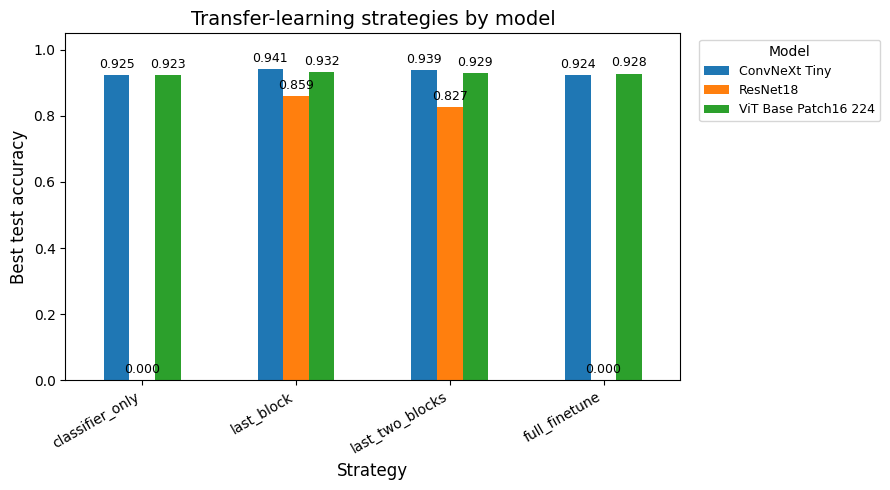

model,ConvNeXt Tiny,ResNet18,ViT Base Patch16 224
strategy,,,
classifier_only,0.9248,NaN,0.9229
last_block,0.9406,0.8591,0.9316
last_two_blocks,0.9387,0.8272,0.9289
full_finetune,0.9237,NaN,0.9283


In [24]:
if len(transfer) > 0:
    transfer = transfer.copy()

    strategy_map = {
        "layer3_layer4": "last_two_blocks",
        "layer4": "last_block",
    }

    transfer["strategy"] = transfer["strategy"].replace(strategy_map)

    pivot = transfer.pivot_table(
        index="strategy",
        columns="model",
        values="test_acc",
        aggfunc="max"
    )

    strategy_order = [
        "classifier_only",
        "last_block",
        "last_two_blocks",
        "full_finetune",
    ]

    pivot = pivot.reindex([s for s in strategy_order if s in pivot.index])

    ax = pivot.plot(kind="bar", figsize=(9, 5))

    plt.ylabel("Best test accuracy", fontsize=12)
    plt.xlabel("Strategy", fontsize=12)
    plt.title("Transfer-learning strategies by model", fontsize=14)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right", fontsize=10)
    plt.yticks(fontsize=10)

    # Put accuracy labels outside bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            label_type="edge",
            padding=3,
            fontsize=9
        )

    # Move legend outside the plot
    plt.legend(
        title="Model",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        title_fontsize=10
    )

    plt.tight_layout()

    save_current_fig("transfer_strategy_comparison.png")

    plt.show()
    display(pivot)

## 8. Performance vs training-cost proxy

If you later add training time, GPU memory, model size, or parameter counts to the CSVs, replace `epochs` with those columns for a stronger efficiency comparison.

Saved: comparison_figures/accuracy_vs_epochs.png


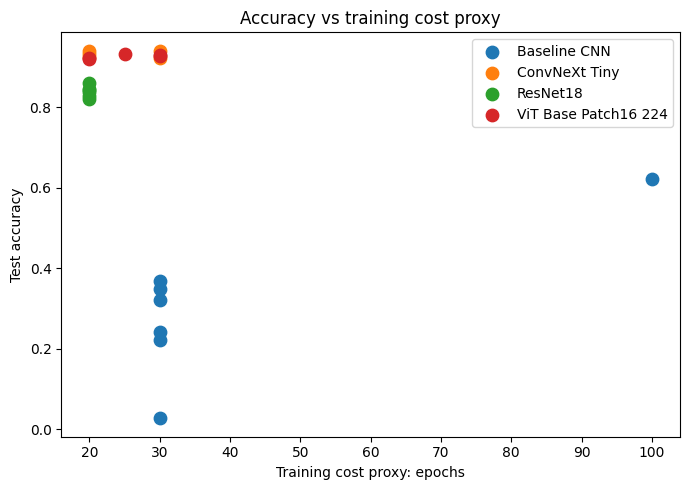

In [19]:
plt.figure(figsize=(7, 5))
for model_name, group in results.groupby("model"):
    plt.scatter(group["training_cost_proxy_epochs"], group["test_acc"], s=80, label=model_name)

plt.xlabel("Training cost proxy: epochs")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs training cost proxy")
plt.legend()
save_current_fig("accuracy_vs_epochs.png")
plt.show()

## 9. Select the best model

Default criterion: highest test accuracy.

In [20]:
# Adjustable model-selection score.
# Current score prioritizes test accuracy, then macro recall, then lower validation-test gap.
ranked = results.copy()
ranked["selection_score"] = (
    0.70 * ranked["test_acc"].fillna(0)
    + 0.20 * ranked["macro_recall"].fillna(0)
    + 0.10 * (1 - ranked["val_test_gap"].abs().fillna(1))
)

selection_cols = [
    "name", "model", "strategy", "lr", "batch_size", "dropout", "augmentation", "epochs",
    "best_val_acc", "test_acc", "macro_precision", "macro_recall", "f1_macro_est", "val_test_gap", "selection_score"
]

ranked[selection_cols].sort_values("selection_score", ascending=False).reset_index(drop=True)

,name,model,strategy,lr,batch_size,dropout,augmentation,epochs,best_val_acc,test_acc,macro_precision,macro_recall,f1_macro_est,val_test_gap,selection_score
0,exp2_convnext_img256,ConvNeXt Tiny,last_block,0.00050,24,0.1,baseline,20,0.9688,0.9406,0.9418,0.9400,0.940899,0.0282,0.94360
1,exp4_convnext_last_two_blocks,ConvNeXt Tiny,last_two_blocks,0.00005,16,0.2,baseline,30,0.9660,0.9387,0.9392,0.9383,0.938750,0.0273,0.94202
2,exp1_convnext_lr_5e4,ConvNeXt Tiny,last_block,0.00050,32,0.1,baseline,20,0.9633,0.9330,0.9345,0.9325,0.933499,0.0303,0.93657
3,exp3_vit_last_block,ViT Base Patch16 224,last_block,0.00010,16,0.1,baseline,25,0.9552,0.9316,0.9330,0.9309,0.931949,0.0236,0.93594
4,exp4_vit_last_two_blocks,ViT Base Patch16 224,last_two_blocks,0.00005,8,0.2,baseline,30,0.9524,0.9289,0.9307,0.9286,0.929649,0.0235,0.93360
5,exp5_vit_full_finetune,ViT Base Patch16 224,full_finetune,0.00001,8,0.2,strong,30,0.9552,0.9283,0.9295,0.9280,0.928749,0.0269,0.93272
6,exp3_convnext_classifier_only,ConvNeXt Tiny,classifier_only,0.00100,32,0.2,strong,20,0.9552,0.9248,0.9283,0.9245,0.926396,0.0304,0.92922
7,exp5_convnext_full_finetune,ConvNeXt Tiny,full_finetune,0.00001,16,0.2,strong,30,0.9538,0.9237,0.9271,0.9236,0.925347,0.0301,0.92830
8,exp1_vit_classifier_lr1e3,ViT Base Patch16 224,classifier_only,0.00100,16,0.1,baseline,20,0.9457,0.9229,0.9248,0.9227,0.923749,0.0228,0.92829
9,exp2_vit_classifier_strong_aug,ViT Base Patch16 224,classifier_only,0.00050,16,0.2,strong,20,0.9402,0.9191,0.9203,0.9186,0.919449,0.0211,0.92498


In [21]:
best = ranked.sort_values("selection_score", ascending=False).iloc[0]
print("Recommended model based on current selection score")
print("- Experiment:", best["name"])
print("- Model:", best["model"])
print("- Strategy:", best["strategy"])
print("- Test accuracy:", round(best["test_acc"], 4))
print("- Macro precision:", round(best["macro_precision"], 4) if pd.notna(best["macro_precision"]) else "N/A")
print("- Macro recall:", round(best["macro_recall"], 4) if pd.notna(best["macro_recall"]) else "N/A")
print("- Validation-test gap:", round(best["val_test_gap"], 4))

Recommended model based on current selection score
- Experiment: exp2_convnext_img256
- Model: ConvNeXt Tiny
- Strategy: last_block
- Test accuracy: 0.9406
- Macro precision: 0.9418
- Macro recall: 0.94
- Validation-test gap: 0.0282


## 10. Export tables for report and presentation

In [22]:
EXPORT_DIR = Path("comparison_exports")
EXPORT_DIR.mkdir(exist_ok=True)

all_experiments.to_csv(EXPORT_DIR / "all_experiments_ranked.csv", index=False)
summary_by_model.to_csv(EXPORT_DIR / "summary_by_model.csv")
best_per_model.to_csv(EXPORT_DIR / "best_per_model.csv", index=False)
ranked[selection_cols].sort_values("selection_score", ascending=False).to_csv(EXPORT_DIR / "model_selection_ranking.csv", index=False)

print("Exported tables to:", EXPORT_DIR.resolve())
print("Exported figures to:", FIG_DIR.resolve())

Exported tables to: /content/comparison_exports
Exported figures to: /content/comparison_figures


## 12. Suggested interpretation from the current CSVs

Based on the uploaded aggregate results:

- The strongest result is **ConvNeXt Tiny, last-block finetuning, image size 256**, with the highest test accuracy among the uploaded runs.
- ConvNeXt generally outperforms ViT in these experiments on test accuracy, precision, and recall.
- Both pretrained architectures strongly outperform the from-scratch baseline CNN.
- The baseline ablations show that removing batch normalization severely damages performance, and strong augmentation was not helpful for the baseline setup.
- For the final report, mention that confusion matrices require saved per-image predictions, not only aggregate experiment CSV rows.